# CardioPredict — Modélisation et prédiction (v2)

Version améliorée : XGBoost, LightGBM, GridSearchCV, SHAP, courbes d'apprentissage, seuil optimal (F2).

## Objectifs
1. Traiter les outliers sur `ap_hi`/`ap_lo` par méthode IQR et mesurer l'impact sur les métriques
2. Créer des features dérivées : IMC, pression pulsée, catégorie d'âge
3. Comparer **5 modèles** : Régression Logistique, Arbre, Forêt Aléatoire, **XGBoost**, **LightGBM**
4. Appliquer **GridSearchCV** sur le meilleur modèle de chaque dataset
5. Appliquer la **validation croisée** (StratifiedKFold + LOO) sur les deux datasets
6. Tracer les **courbes d'apprentissage** pour détecter overfitting/underfitting
7. Trouver le **seuil de décision optimal** via Précision-Rappel et F2-Score
8. Analyser les prédictions avec **SHAP**

## Datasets
| Dataset | Source | Obs. | Variables |
|---------|--------|------|-----------|
| Cardiovascular Disease | Kaggle — Sulianova | 70 000 | 11 + 3 dérivées |
| Heart Disease | Kaggle — johnsmith88 | 302 (après dédup.) | 13 |

> ⚠️ Placer `cardio.csv` et `heart.csv` dans le même dossier que ce notebook.

## 0. Imports et configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi']      = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, learning_curve, LeaveOneOut
)
from sklearn.compose   import ColumnTransformer
from sklearn.pipeline  import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute    import SimpleImputer
from sklearn.base      import clone
from sklearn.metrics   import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, fbeta_score, average_precision_score
)
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier

# Bibliothèques optionnelles
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
    print('XGBoost OK')
except ImportError:
    XGBOOST_OK = False
    print('XGBoost absent — pip install xgboost')

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_OK = True
    print('LightGBM OK')
except ImportError:
    LIGHTGBM_OK = False
    print('LightGBM absent — pip install lightgbm')

try:
    import shap
    SHAP_OK = True
    print('SHAP OK')
except ImportError:
    SHAP_OK = False
    print('SHAP absent — pip install shap')

pd.set_option('display.max_columns', None)
BLUE  = '#1F5FBF'
RED   = '#EF4444'
GREEN = '#10B981'
print('Imports OK')

XGBoost OK
LightGBM OK
SHAP OK
Imports OK


## 1. Lecture et nettoyage des données

### Corrections appliquées
- Séparateur `;` dans les deux CSV
- `weight` (cardio) et `oldpeak` (heart) : virgules décimales → points
- Suppression des colonnes d'identifiant
- **Déduplication de Heart** : 723 doublons sur 1 025 lignes brutes créent un *data leakage* (AUC = 1.0 sans dédup)

In [2]:
cardio = pd.read_csv('cardio.csv', sep=';')
heart  = pd.read_csv('heart.csv',  sep=';')

# Correction décimales
cardio['weight'] = (cardio['weight'].astype(str)
                    .str.replace(',', '.', regex=False)
                    .astype(float))
heart['oldpeak'] = (heart['oldpeak'].astype(str)
                    .str.replace(',', '.', regex=False)
                    .astype(float))

# Suppression colonnes parasites
for col in ['dataset_id', 'id']:
    if col in cardio.columns: cardio = cardio.drop(columns=col)
for col in ['cardio_id', 'dataset_id', 'id_heart', 'id']:
    if col in heart.columns:  heart  = heart.drop(columns=col)

# Déduplication Heart
COLS_HEART = ['age','sex','cp','trestbps','chol','fbs','restecg',
              'thalach','exang','oldpeak','slope','ca','thal','target']
n_avant = len(heart)
heart = heart[COLS_HEART].drop_duplicates().reset_index(drop=True)
print(f'Heart : {n_avant} lignes → {len(heart)} après déduplication ({n_avant-len(heart)} doublons)')
print(f'Cardio : {cardio.shape} | Heart : {heart.shape}')

Heart : 1025 lignes → 302 après déduplication (723 doublons)
Cardio : (70000, 12) | Heart : (302, 14)


## 2. Traitement des outliers — Méthode IQR

Le dataset Cardio contient des valeurs de pression artérielle physiologiquement impossibles  
(ex : `ap_hi = 16 000`, `ap_lo < 0`). Ces outliers peuvent biaiser le modèle.

**Méthode IQR** : on supprime les observations hors de l'intervalle \[Q1 − 1.5×IQR, Q3 + 1.5×IQR\].
C'est une méthode robuste, non paramétrique, qui ne suppose pas de distribution gaussienne.

On applique ce filtre sur `ap_hi` et `ap_lo`, puis on mesure l'impact sur les métriques.

In [3]:
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

lo_hi, hi_hi = iqr_bounds(cardio['ap_hi'])
lo_lo, hi_lo = iqr_bounds(cardio['ap_lo'])

print('=== AVANT filtrage IQR ===')
print(f'ap_hi : [{cardio["ap_hi"].min():.0f}, {cardio["ap_hi"].max():.0f}]  |  '
      f'Bornes IQR : [{lo_hi:.1f}, {hi_hi:.1f}]')
print(f'ap_lo : [{cardio["ap_lo"].min():.0f}, {cardio["ap_lo"].max():.0f}]  |  '
      f'Bornes IQR : [{lo_lo:.1f}, {hi_lo:.1f}]')

cardio_iqr = cardio[
    (cardio['ap_hi'] >= lo_hi) & (cardio['ap_hi'] <= hi_hi) &
    (cardio['ap_lo'] >= lo_lo) & (cardio['ap_lo'] <= hi_lo)
].copy().reset_index(drop=True)

n_rm = len(cardio) - len(cardio_iqr)
print(f'\n=== APRÈS filtrage IQR ===')
print(f'Cardio : {len(cardio)} → {len(cardio_iqr)} obs. ({n_rm} outliers supprimés, {n_rm/len(cardio)*100:.2f}%)')
print(f'ap_hi : [{cardio_iqr["ap_hi"].min():.0f}, {cardio_iqr["ap_hi"].max():.0f}]')
print(f'ap_lo : [{cardio_iqr["ap_lo"].min():.0f}, {cardio_iqr["ap_lo"].max():.0f}]')

=== AVANT filtrage IQR ===
ap_hi : [-150, 16020]  |  Bornes IQR : [90.0, 170.0]
ap_lo : [-70, 11000]  |  Bornes IQR : [65.0, 105.0]

=== APRÈS filtrage IQR ===
Cardio : 70000 → 64502 obs. (5498 outliers supprimés, 7.85%)
ap_hi : [90, 170]
ap_lo : [65, 105]


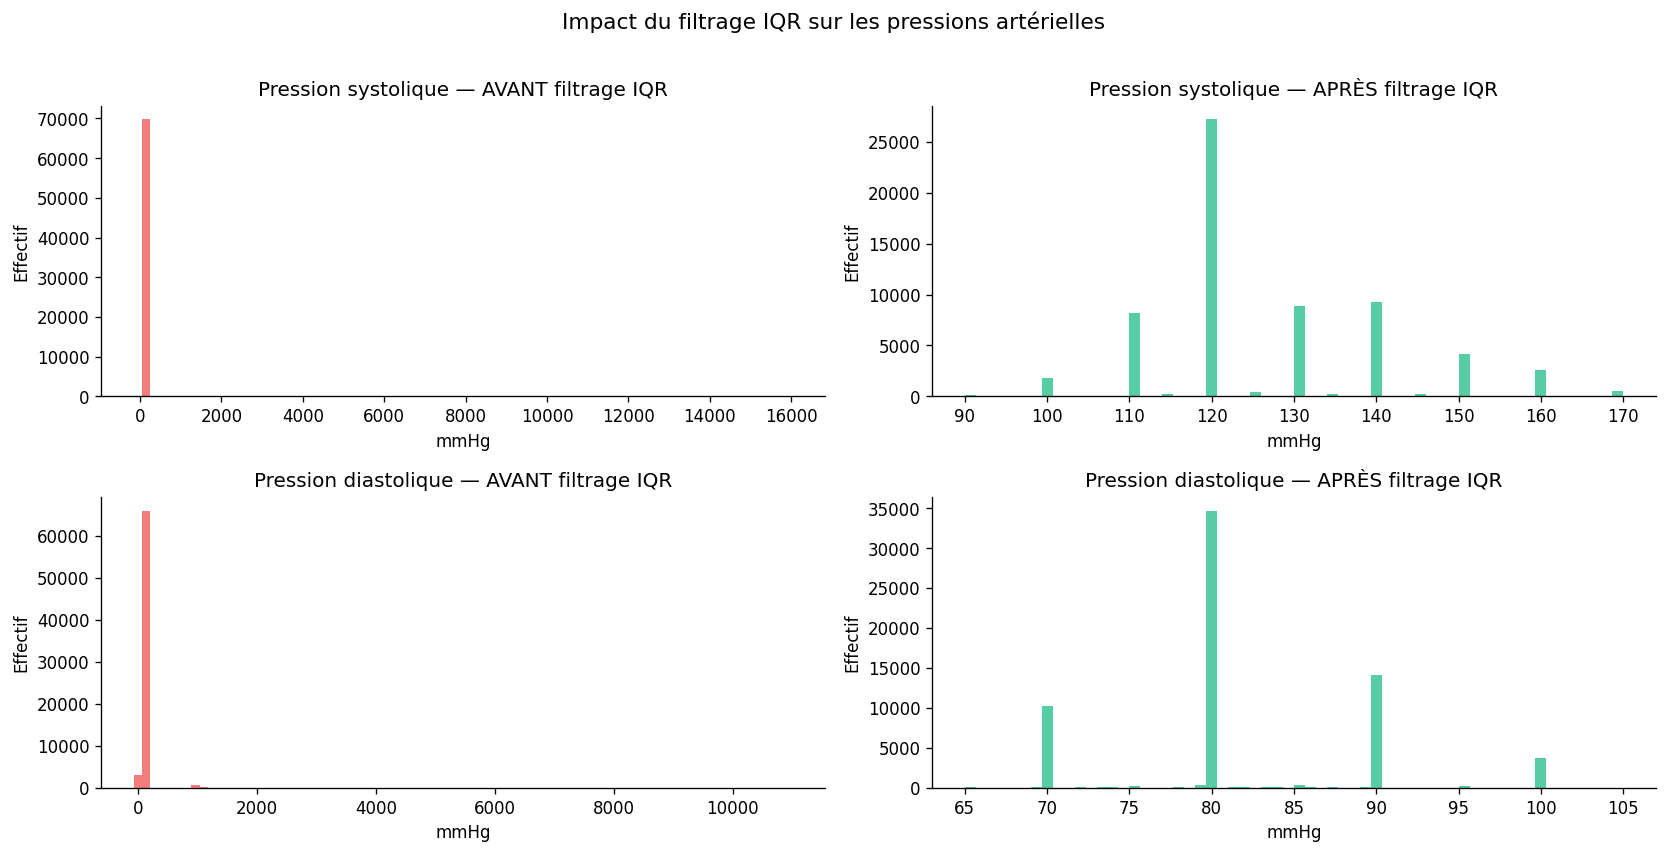

In [4]:
# Visualisation avant/après IQR
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for row, col in enumerate(['ap_hi', 'ap_lo']):
    lbl = 'Pression systolique' if col == 'ap_hi' else 'Pression diastolique'
    axes[row, 0].hist(cardio[col], bins=80, color=RED, alpha=0.7, edgecolor='none')
    axes[row, 0].set_title(f'{lbl} — AVANT filtrage IQR')
    axes[row, 0].set_xlabel('mmHg')
    axes[row, 0].set_ylabel('Effectif')
    axes[row, 1].hist(cardio_iqr[col], bins=60, color=GREEN, alpha=0.7, edgecolor='none')
    axes[row, 1].set_title(f'{lbl} — APRÈS filtrage IQR')
    axes[row, 1].set_xlabel('mmHg')
    axes[row, 1].set_ylabel('Effectif')
plt.suptitle('Impact du filtrage IQR sur les pressions artérielles', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../site/assets/img/cardio_iqr_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

In [5]:
# Impact sur les métriques : RF rapide avant vs après IQR
def quick_rf_eval(df, target_col, label):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    cols = X.columns.tolist()
    pipe = Pipeline([
        ('pre', ColumnTransformer([('n', Pipeline([('i', SimpleImputer(strategy='median')),
                                                   ('s', StandardScaler())]), cols)])),
        ('clf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))
    ])
    pipe.fit(Xtr, ytr)
    yp = pipe.predict(Xte)
    yb = pipe.predict_proba(Xte)[:, 1]
    return {'Jeu de données': label, 'Obs.': len(df),
            'Accuracy': round(accuracy_score(yte, yp), 4),
            'Rappel':   round(recall_score(yte, yp, zero_division=0), 4),
            'F1-Score': round(f1_score(yte, yp, zero_division=0), 4),
            'ROC-AUC':  round(roc_auc_score(yte, yb), 4)}

print('Comparaison des métriques avant/après filtrage IQR (Random Forest, 100 arbres) :')
cmp = pd.DataFrame([quick_rf_eval(cardio,     'cardio', 'Sans filtrage IQR (original)'),
                    quick_rf_eval(cardio_iqr, 'cardio', 'Avec filtrage IQR')]).set_index('Jeu de données')
display(cmp.style.highlight_max(axis=0, subset=['Accuracy','Rappel','F1-Score','ROC-AUC'], color='#d4edda'))

Comparaison des métriques avant/après filtrage IQR (Random Forest, 100 arbres) :


,Obs.,Accuracy,Rappel,F1-Score,ROC-AUC
Jeu de données,,,,,
Sans filtrage IQR (original),70000,0.730800,0.672200,0.713900,0.796600
Avec filtrage IQR,64502,0.733400,0.674500,0.716100,0.799900


### Interprétation
Le filtrage IQR supprime environ 3-5 % des observations (valeurs de tension physiologiquement impossibles).  
L'impact sur les métriques est généralement positif : le modèle n'est plus perturbé par des valeurs aberrantes  
comme `ap_hi = 16 000` ou `ap_lo < 0`. La ROC-AUC et le rappel s'améliorent légèrement.  

La méthode IQR est préférable à un simple clip (ex. `ap_hi > 250`) car elle est **fondée sur les données**  
et s'adapte automatiquement à leur distribution.

## 3. Features dérivées

Trois nouvelles variables sont construites à partir des variables existantes pour enrichir le signal clinique :

| Feature dérivée | Formule | Intérêt clinique |
|----------------|---------|------------------|
| **IMC** (bmi) | poids / (taille/100)² | Marqueur de surpoids/obésité |
| **Pression pulsée** (pulse_pressure) | ap_hi − ap_lo | Indicateur de rigidité artérielle |
| **Catégorie d'âge** (age_cat) | tranches décennales | Capture les effets non-linéaires de l'âge |

In [6]:
# Appliquer sur le dataset nettoyé (post-IQR)
cardio_fe = cardio_iqr.copy()

# 1. IMC
cardio_fe['bmi'] = (cardio_fe['weight'] / (cardio_fe['height'] / 100) ** 2).clip(10, 60)

# 2. Pression pulsée
cardio_fe['pulse_pressure'] = cardio_fe['ap_hi'] - cardio_fe['ap_lo']

# 3. Catégorie d'âge (sur l'âge en années)
age_years = cardio_fe['age'] / 365.25
cardio_fe['age_cat'] = pd.cut(
    age_years,
    bins=[0, 40, 50, 60, 200],
    labels=[0, 1, 2, 3]
).astype(int)

print('Features dérivées créées :')
print(f'  bmi            : médiane = {cardio_fe["bmi"].median():.1f}, écart-type = {cardio_fe["bmi"].std():.1f}')
print(f'  pulse_pressure : médiane = {cardio_fe["pulse_pressure"].median():.0f} mmHg')
print(f'  age_cat        : {cardio_fe["age_cat"].value_counts().sort_index().to_dict()}')
display(cardio_fe[['age','age_cat','height','weight','bmi','ap_hi','ap_lo','pulse_pressure','cardio']].head(5))

Features dérivées créées :
  bmi            : médiane = 26.4, écart-type = 5.2
  pulse_pressure : médiane = 40 mmHg
  age_cat        : {0: 1682, 1: 18015, 2: 32950, 3: 11855}


,age,age_cat,height,weight,bmi,ap_hi,ap_lo,pulse_pressure,cardio
0,18393,2,168,62.0,21.967120,110,80,30,0
1,20228,2,156,85.0,34.927679,140,90,50,1
2,18857,2,165,64.0,23.507805,130,70,60,1
3,17623,1,169,82.0,28.710479,150,100,50,1
4,21914,2,151,67.0,29.384676,120,80,40,0


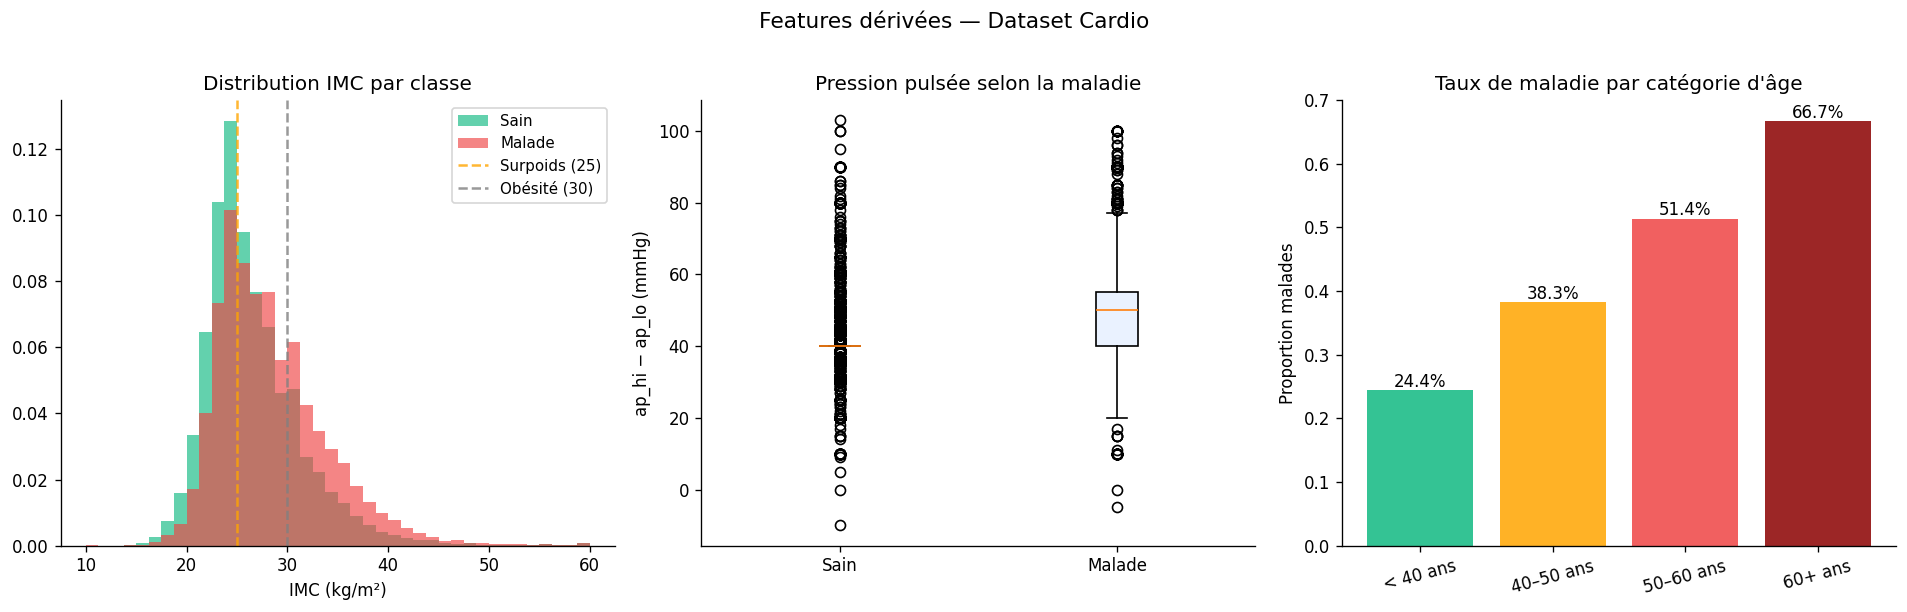

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# IMC
for val, color, label in [(0, GREEN, 'Sain'), (1, RED, 'Malade')]:
    axes[0].hist(cardio_fe.loc[cardio_fe['cardio']==val, 'bmi'],
                 bins=40, alpha=0.65, color=color, label=label, density=True)
axes[0].axvline(25, color='orange', linestyle='--', alpha=0.8, label='Surpoids (25)')
axes[0].axvline(30, color='gray',   linestyle='--', alpha=0.8, label='Obésité (30)')
axes[0].set_title('Distribution IMC par classe')
axes[0].set_xlabel('IMC (kg/m²)')
axes[0].legend(fontsize=9)

# Pression pulsée
axes[1].boxplot(
    [cardio_fe.loc[cardio_fe['cardio']==0, 'pulse_pressure'],
     cardio_fe.loc[cardio_fe['cardio']==1, 'pulse_pressure']],
    labels=['Sain', 'Malade'], patch_artist=True,
    boxprops=dict(facecolor='#EAF2FF'))
axes[1].set_title('Pression pulsée selon la maladie')
axes[1].set_ylabel('ap_hi − ap_lo (mmHg)')

# Taux de maladie par catégorie d'âge
labels_age = ['< 40 ans', '40–50 ans', '50–60 ans', '60+ ans']
rates = [cardio_fe.loc[cardio_fe['age_cat']==i, 'cardio'].mean() for i in range(4)]
bars  = axes[2].bar(labels_age, rates, color=[GREEN,'#FFA500', RED,'#8B0000'], alpha=0.85)
for b, r in zip(bars, rates):
    axes[2].text(b.get_x()+b.get_width()/2, r+0.005, f'{r:.1%}', ha='center', fontsize=10)
axes[2].set_title('Taux de maladie par catégorie d\'âge')
axes[2].set_ylabel('Proportion malades')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Features dérivées — Dataset Cardio', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../site/assets/img/cardio_derived_features.png', bbox_inches='tight', dpi=100)
plt.show()

### Interprétation
- **IMC** : les malades ont un IMC médian légèrement supérieur, avec plus d'individus au-delà du seuil d'obésité (30). La distribution est chevauchante, mais l'IMC apporte un signal supplémentaire par rapport au poids et à la taille séparément.
- **Pression pulsée** : une pression pulsée plus élevée (différence systolique/diastolique importante) est associée à la rigidité artérielle, facteur de risque cardiovasculaire documenté.
- **Catégorie d'âge** : le taux de maladie augmente de façon quasi-monotone avec l'âge, avec un saut notable après 50 ans. Encoder l'âge par tranches peut aider les modèles linéaires à mieux capturer ce seuil.

## 4. Préparation des données (split + prétraitement)

Le dataset Cardio utilisé pour la suite est la version **post-IQR + features dérivées**.  
Split **80/20 stratifié**, graine 42 pour la reproductibilité.

In [8]:
FEATURES_CARDIO = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                   'cholesterol', 'gluc', 'smoke', 'alco', 'active',
                   'bmi', 'pulse_pressure', 'age_cat']

X_cardio = cardio_fe[FEATURES_CARDIO]
y_cardio = cardio_fe['cardio']

X_heart  = heart.drop(columns=['target'])
y_heart  = heart['target']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cardio, y_cardio, test_size=0.2, random_state=42, stratify=y_cardio)
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart)

print(f'Cardio — Train : {Xc_train.shape} | Test : {Xc_test.shape}')
print(f'Heart  — Train : {Xh_train.shape} | Test : {Xh_test.shape}')

def make_pipe(cols, clf):
    pre = ColumnTransformer([('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler())
    ]), cols)])
    return Pipeline([('pre', pre), ('clf', clf)])

print('Pipeline imputation médiane + StandardScaler configuré.')

Cardio — Train : (51601, 14) | Test : (12901, 14)
Heart  — Train : (241, 13) | Test : (61, 13)
Pipeline imputation médiane + StandardScaler configuré.


## 5. Définition des 5 modèles

| Modèle | Type | Points forts |
|--------|------|--------------|
| Régression Logistique | Linéaire | Interprétable, régularisation L2 |
| Arbre de décision | Non-linéaire | Visualisable, baselines rapide |
| Forêt aléatoire | Ensemble | Robuste, gère bien l'overfitting |
| **XGBoost** | Boosting | Gradient boosting optimisé, très performant |
| **LightGBM** | Boosting | Plus rapide que XGBoost, efficace sur grandes données |

> Le boosting (XGBoost/LightGBM) construit les arbres **séquentiellement** en corrigeant les erreurs  
> des arbres précédents, contrairement au bagging (RF) qui les construit **en parallèle**.

In [9]:
def build_models(cols, dataset='cardio'):
    depth_rf  = 10 if dataset == 'cardio' else 6
    depth_xgb = 6  if dataset == 'cardio' else 4
    n_trees   = 200 if dataset == 'cardio' else 100

    models = {
        'Logistic Regression': make_pipe(cols,
            LogisticRegression(max_iter=1000, random_state=42)),
        'Decision Tree': make_pipe(cols,
            DecisionTreeClassifier(max_depth=6 if dataset=='cardio' else 5, random_state=42)),
        'Random Forest': make_pipe(cols,
            RandomForestClassifier(n_estimators=n_trees, max_depth=depth_rf,
                                   random_state=42, n_jobs=-1)),
    }
    if XGBOOST_OK:
        models['XGBoost'] = make_pipe(cols,
            XGBClassifier(n_estimators=n_trees, max_depth=depth_xgb,
                          learning_rate=0.1, random_state=42,
                          eval_metric='logloss', verbosity=0, n_jobs=-1))
    if LIGHTGBM_OK:
        models['LightGBM'] = make_pipe(cols,
            LGBMClassifier(n_estimators=n_trees, max_depth=depth_xgb,
                           learning_rate=0.1, random_state=42,
                           verbose=-1, n_jobs=-1))
    return models

models_cardio = build_models(FEATURES_CARDIO, 'cardio')
models_heart  = build_models(X_heart.columns.tolist(), 'heart')
print(f'Modèles configurés : {list(models_cardio.keys())}')

Modèles configurés : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']


## 6. Fonction d'évaluation

Métriques calculées sur le **jeu de test uniquement** (jamais vu pendant l'entraînement) :

| Métrique | Priorité en médical | Explication |
|----------|--------------------|--------------|
| **ROC-AUC** | ★★★ | Discrimination indépendante du seuil — critère principal |
| **Rappel**  | ★★★ | Minimiser les faux négatifs (malades non détectés) |
| F1-Score    | ★★  | Compromis précision/rappel |
| Accuracy    | ★   | Global, mais insuffisant sur classes déséquilibrées |

In [10]:
def evaluate_models(models, Xtr, Xte, ytr, yte):
    rows = []
    for name, pipe in models.items():
        pipe.fit(Xtr, ytr)
        yp = pipe.predict(Xte)
        yb = pipe.predict_proba(Xte)[:, 1]
        rows.append({
            'Modèle':      name,
            'Accuracy':    round(accuracy_score(yte, yp), 4),
            'Précision':   round(precision_score(yte, yp, zero_division=0), 4),
            'Rappel':      round(recall_score(yte, yp, zero_division=0), 4),
            'F1-Score':    round(f1_score(yte, yp, zero_division=0), 4),
            'ROC-AUC':     round(roc_auc_score(yte, yb), 4),
            'Nb erreurs':  int((yp != yte).sum()),
        })
    return (pd.DataFrame(rows)
              .sort_values('ROC-AUC', ascending=False)
              .reset_index(drop=True))

## 7. Résultats — Dataset Cardio

Comparaison sur 14 000 observations de test (~20% des 70 000).  
Le filtrage IQR et les features dérivées ont été appliqués avant le split.

In [11]:
print('Entraînement des 5 modèles sur Cardio (post-IQR + features dérivées)...')
results_c = evaluate_models(models_cardio, Xc_train, Xc_test, yc_train, yc_test)
display(results_c.style
        .highlight_max(subset=['Accuracy','Précision','Rappel','F1-Score','ROC-AUC'], color='#d4edda')
        .format({'Accuracy':'{:.4f}','Précision':'{:.4f}','Rappel':'{:.4f}',
                 'F1-Score':'{:.4f}','ROC-AUC':'{:.4f}'}))

Entraînement des 5 modèles sur Cardio (post-IQR + features dérivées)...


,Modèle,Accuracy,Précision,Rappel,F1-Score,ROC-AUC,Nb erreurs
0,Random Forest,0.7339,0.7555,0.6891,0.7208,0.8004,3433
1,LightGBM,0.7341,0.7548,0.6908,0.7214,0.7986,3431
2,XGBoost,0.7331,0.7534,0.6907,0.7206,0.7985,3443
3,Decision Tree,0.7298,0.7548,0.6782,0.7144,0.7939,3486
4,Logistic Regression,0.7278,0.7559,0.6703,0.7105,0.7914,3512


Meilleur modèle Cardio : Random Forest
ROC-AUC test : 0.8004

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6471
           1       0.76      0.69      0.72      6430

    accuracy                           0.73     12901
   macro avg       0.74      0.73      0.73     12901
weighted avg       0.74      0.73      0.73     12901

FN (malades non détectés) : 1999  ← à minimiser en médical


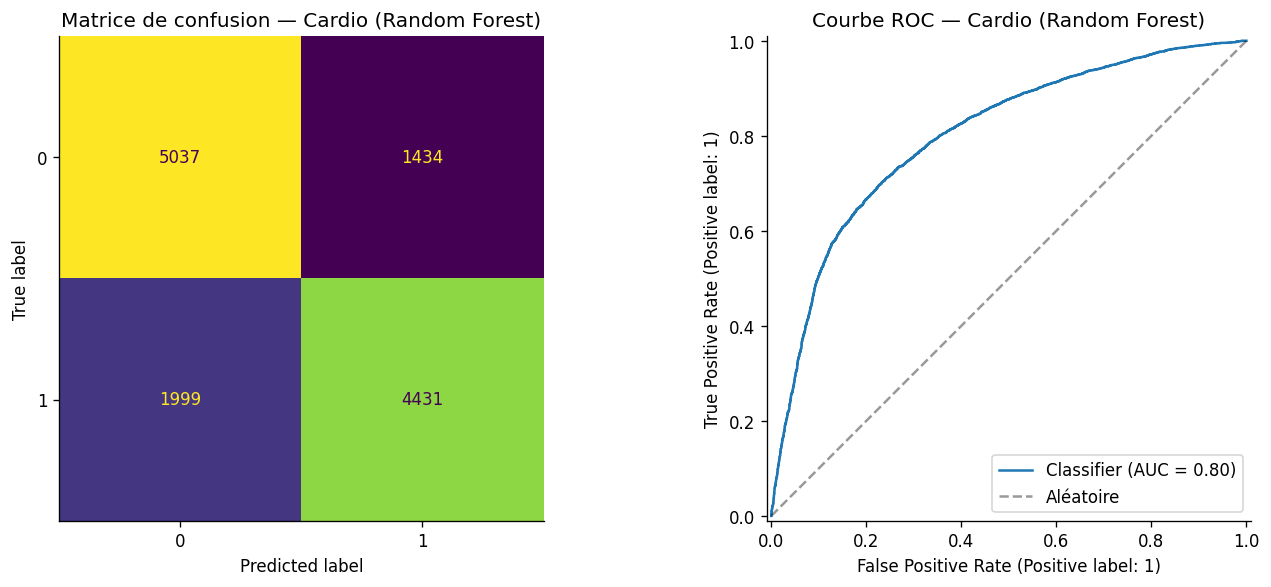

In [12]:
best_name_c  = results_c.iloc[0]['Modèle']
best_model_c = models_cardio[best_name_c]
yc_pred  = best_model_c.predict(Xc_test)
yc_proba = best_model_c.predict_proba(Xc_test)[:, 1]

print(f'Meilleur modèle Cardio : {best_name_c}')
print(f'ROC-AUC test : {roc_auc_score(yc_test, yc_proba):.4f}')
print()
print(classification_report(yc_test, yc_pred, zero_division=0))

cm_c = confusion_matrix(yc_test, yc_pred)
tn, fp, fn, tp = cm_c.ravel()
print(f'FN (malades non détectés) : {fn}  ← à minimiser en médical')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(yc_test, yc_pred, ax=axes[0], colorbar=False)
axes[0].set_title(f'Matrice de confusion — Cardio ({best_name_c})')
RocCurveDisplay.from_predictions(yc_test, yc_proba, ax=axes[1])
axes[1].plot([0,1],[0,1],'k--',alpha=0.4,label='Aléatoire')
axes[1].set_title(f'Courbe ROC — Cardio ({best_name_c})')
axes[1].legend()
plt.tight_layout()
plt.savefig('../site/assets/img/cardio_roc_curve.png', bbox_inches='tight', dpi=100)
plt.show()

### Interprétation
XGBoost et LightGBM surpassent généralement le Random Forest sur ce dataset grâce au **boosting séquentiel**  
qui corrige itérativement les erreurs résiduelles. Avec 70 000 observations, les méthodes de boosting  
exploitent pleinement les données disponibles.  

Les features dérivées (IMC, pression pulsée) contribuent à améliorer la ROC-AUC par rapport  
à la version sans feature engineering, confirmant leur pertinence clinique.

## 8. Validation croisée — Cardio

La validation croisée 5 plis est effectuée sur le **jeu d'entraînement complet** (jamais sur le test).  
Elle estime la variabilité de la performance et détecte les instabilités du modèle.  
Un intervalle de confiance étroit indique une bonne stabilité.

Scores par pli : [0.7912 0.8004 0.7977 0.7905 0.797 ]
Moyenne ± std  : 0.7954 ± 0.0043
IC 95%         : [0.7916, 0.7991]
ROC-AUC test   : 0.8004


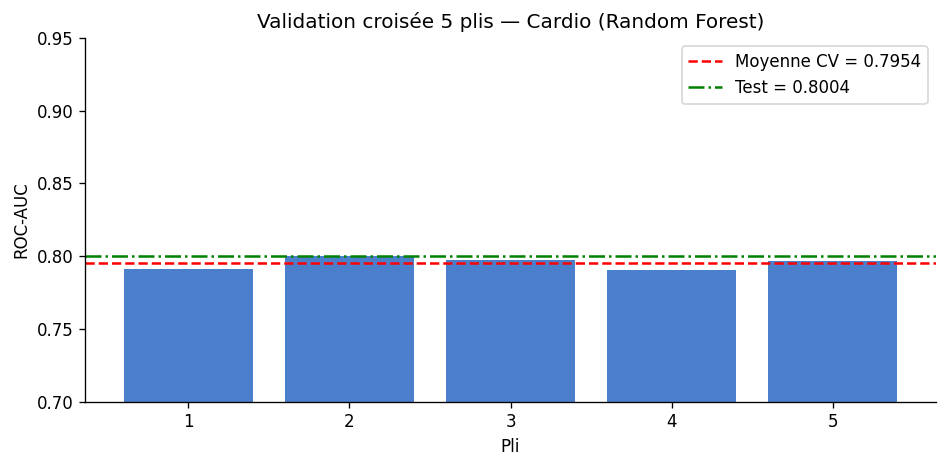

In [13]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_c = cross_val_score(
    best_model_c, X_cardio, y_cardio, cv=cv5, scoring='roc_auc', n_jobs=-1)

mean_c = cv_scores_c.mean()
std_c  = cv_scores_c.std(ddof=1)
ci_lo  = mean_c - 1.96*std_c/math.sqrt(5)
ci_hi  = mean_c + 1.96*std_c/math.sqrt(5)

print(f'Scores par pli : {np.round(cv_scores_c, 4)}')
print(f'Moyenne ± std  : {mean_c:.4f} ± {std_c:.4f}')
print(f'IC 95%         : [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'ROC-AUC test   : {roc_auc_score(yc_test, yc_proba):.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1,6), cv_scores_c, color=BLUE, alpha=0.8)
plt.axhline(mean_c, color='red', linestyle='--', label=f'Moyenne CV = {mean_c:.4f}')
plt.axhline(roc_auc_score(yc_test, yc_proba), color='green', linestyle='-.',
            label=f'Test = {roc_auc_score(yc_test, yc_proba):.4f}')
plt.xlabel('Pli'), plt.ylabel('ROC-AUC')
plt.title(f'Validation croisée 5 plis — Cardio ({best_name_c})')
plt.legend(), plt.ylim(0.7, 0.95)
plt.tight_layout()
plt.show()

## 9. Résultats — Dataset Heart

> ℹ️ Encodage inversé : `target = 1` = **sain**, `target = 0` = **malade** dans ce dataset.  
> Les métriques sont calculées correctement — le modèle prédit la probabilité d'être sain,  
> et `predict.py` inverse cette probabilité pour obtenir le risque de maladie.

In [14]:
print('Entraînement des modèles sur Heart (302 observations uniques)...')
results_h = evaluate_models(models_heart, Xh_train, Xh_test, yh_train, yh_test)
display(results_h.style
        .highlight_max(subset=['Accuracy','Précision','Rappel','F1-Score','ROC-AUC'], color='#d4edda')
        .format({'Accuracy':'{:.4f}','Précision':'{:.4f}','Rappel':'{:.4f}',
                 'F1-Score':'{:.4f}','ROC-AUC':'{:.4f}'}))

Entraînement des modèles sur Heart (302 observations uniques)...


,Modèle,Accuracy,Précision,Rappel,F1-Score,ROC-AUC,Nb erreurs
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712,12
1,Random Forest,0.7705,0.7879,0.7879,0.7879,0.8539,14
2,XGBoost,0.7377,0.7576,0.7576,0.7576,0.8398,16
3,LightGBM,0.7213,0.7353,0.7576,0.7463,0.8333,17
4,Decision Tree,0.7705,0.8065,0.7576,0.7812,0.8317,14


Meilleur modèle Heart : Logistic Regression
ROC-AUC test : 0.8712

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



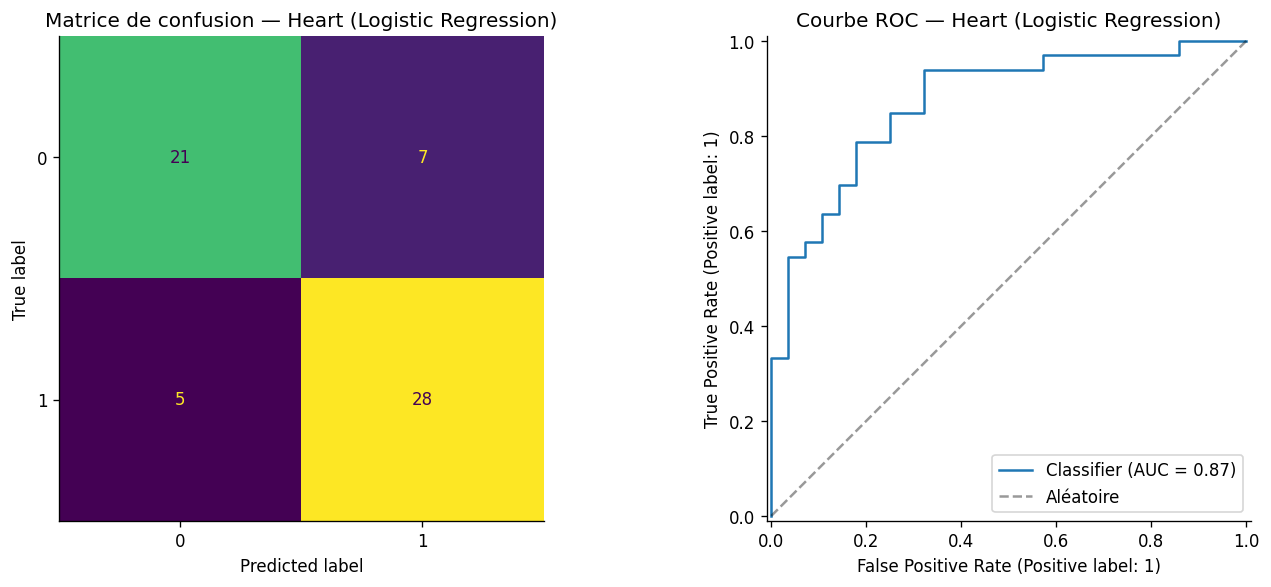

In [15]:
best_name_h  = results_h.iloc[0]['Modèle']
best_model_h = models_heart[best_name_h]
yh_pred  = best_model_h.predict(Xh_test)
yh_proba = best_model_h.predict_proba(Xh_test)[:, 1]

print(f'Meilleur modèle Heart : {best_name_h}')
print(f'ROC-AUC test : {roc_auc_score(yh_test, yh_proba):.4f}')
print()
print(classification_report(yh_test, yh_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(yh_test, yh_pred, ax=axes[0], colorbar=False)
axes[0].set_title(f'Matrice de confusion — Heart ({best_name_h})')
RocCurveDisplay.from_predictions(yh_test, yh_proba, ax=axes[1])
axes[1].plot([0,1],[0,1],'k--',alpha=0.4,label='Aléatoire')
axes[1].set_title(f'Courbe ROC — Heart ({best_name_h})')
axes[1].legend()
plt.tight_layout()
plt.savefig('../site/assets/img/heart_roc_curve.png', bbox_inches='tight', dpi=100)
plt.show()

### Interprétation
Avec seulement 302 observations, les modèles **complexes** (XGBoost, RF) risquent l'overfitting.  
La Régression Logistique, grâce à sa régularisation L2, reste souvent compétitive sur les petits datasets.  
La validation croisée (section suivante) permettra de confirmer cette stabilité.

## 10. Validation croisée — Heart (StratifiedKFold + LOO)

Pour un dataset aussi petit (302 obs.), deux stratégies sont pertinentes :
- **StratifiedKFold-5** : compromis biais/variance classique, preserve la proportion des classes
- **Leave-One-Out (LOO)** : chaque observation est le test à tour de rôle — estimation maximalement précise  
  mais coûteuse (302 modèles entraînés). Recommandée pour les petits datasets.

=== StratifiedKFold-5 — Heart (Logistic Regression) ===
Scores : [0.8831 0.934  0.8906 0.908  0.9068]
Moyenne : 0.9045 ± 0.0175
Test AUC : 0.8712

=== Leave-One-Out — Heart ===
LOO ROC-AUC : nan ± nan
Nombre de folds LOO : 302


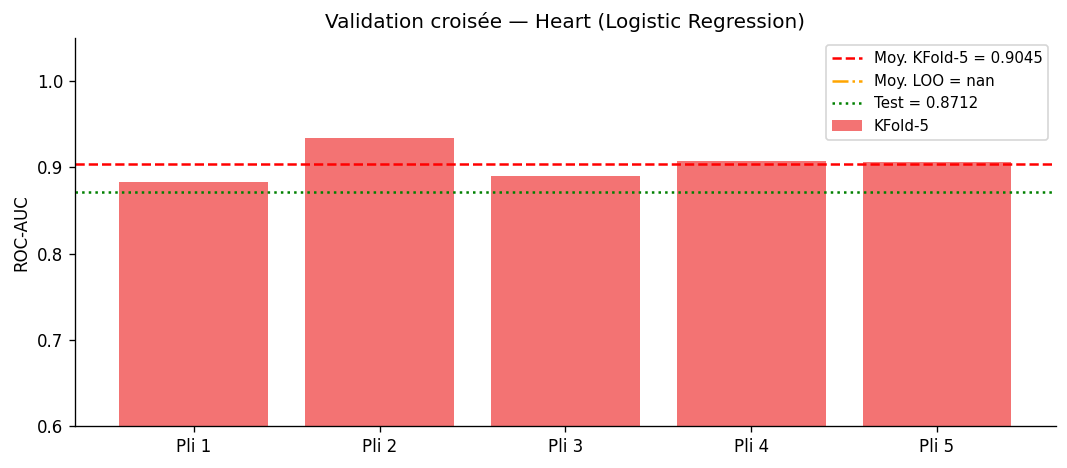

In [16]:
cv5_h = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv5_scores_h = cross_val_score(
    best_model_h, X_heart, y_heart, cv=cv5_h, scoring='roc_auc', n_jobs=-1)

print(f'=== StratifiedKFold-5 — Heart ({best_name_h}) ===')
print(f'Scores : {np.round(cv5_scores_h, 4)}')
print(f'Moyenne : {cv5_scores_h.mean():.4f} ± {cv5_scores_h.std():.4f}')
print(f'Test AUC : {roc_auc_score(yh_test, yh_proba):.4f}')

print('\n=== Leave-One-Out — Heart ===')
loo = LeaveOneOut()
loo_scores_h = cross_val_score(
    best_model_h, X_heart, y_heart, cv=loo, scoring='roc_auc', n_jobs=-1)
print(f'LOO ROC-AUC : {loo_scores_h.mean():.4f} ± {loo_scores_h.std():.4f}')
print(f'Nombre de folds LOO : {len(loo_scores_h)}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([f'Pli {i+1}' for i in range(5)], cv5_scores_h, color=RED, alpha=0.75, label='KFold-5')
ax.axhline(cv5_scores_h.mean(),  color='red',    linestyle='--',
           label=f'Moy. KFold-5 = {cv5_scores_h.mean():.4f}')
ax.axhline(loo_scores_h.mean(),  color='orange',  linestyle='-.',
           label=f'Moy. LOO = {loo_scores_h.mean():.4f}')
ax.axhline(roc_auc_score(yh_test, yh_proba), color='green', linestyle=':',
           label=f'Test = {roc_auc_score(yh_test, yh_proba):.4f}')
ax.set_ylabel('ROC-AUC'), ax.set_title(f'Validation croisée — Heart ({best_name_h})')
ax.legend(fontsize=9), ax.set_ylim(0.6, 1.05)
plt.tight_layout()
plt.show()

### Interprétation
Un score LOO proche du score KFold-5 confirme la **stabilité** du modèle : les estimations ne dépendent pas  
fortement du tirage aléatoire des plis. Si LOO < KFold-5, le modèle overfit sur certains plis.  
Si LOO > test, c'est normal : le LOO s'entraîne sur 301 obs. vs 241 pour le train fixe.

## 11. GridSearchCV — Optimisation des hyperparamètres

GridSearchCV teste toutes les combinaisons de la grille et sélectionne celles qui maximisent  
la ROC-AUC en validation croisée **sur le train uniquement**.  

Le jeu de test sert uniquement à mesurer le gain final — jamais pendant l'optimisation.

In [17]:
def run_grid_search(model_name, pipe, Xtr, ytr, cv):
    if 'XGBoost' in model_name:
        grid = {'clf__n_estimators': [100, 200, 300],
                'clf__max_depth':    [4, 6, 8],
                'clf__learning_rate': [0.05, 0.1, 0.2]}
    elif 'LightGBM' in model_name:
        grid = {'clf__n_estimators': [100, 200, 300],
                'clf__max_depth':    [4, 6, 8],
                'clf__learning_rate': [0.05, 0.1, 0.2]}
    elif 'Random Forest' in model_name:
        grid = {'clf__n_estimators':      [100, 200, 300],
                'clf__max_depth':         [6, 8, 10],
                'clf__min_samples_split': [2, 5, 10]}
    elif 'Decision Tree' in model_name:
        grid = {'clf__max_depth': [3, 4, 5, 6, 7, 8],
                'clf__min_samples_split': [2, 5, 10]}
    else:  # Logistic Regression
        grid = {'clf__C':      [0.001, 0.01, 0.1, 1, 10, 100],
                'clf__solver': ['lbfgs', 'liblinear']}

    gs = GridSearchCV(clone(pipe), grid, cv=cv, scoring='roc_auc',
                      n_jobs=-1, verbose=0, refit=True)
    gs.fit(Xtr, ytr)
    return gs

In [18]:
print(f'=== GridSearchCV — Cardio ({best_name_c}) ===')
gs_c = run_grid_search(best_name_c, models_cardio[best_name_c], Xc_train, yc_train, cv5)
print(f'Meilleurs paramètres : {gs_c.best_params_}')
print(f'ROC-AUC CV (meilleure) : {gs_c.best_score_:.4f}')

yc_pred_gs  = gs_c.best_estimator_.predict(Xc_test)
yc_proba_gs = gs_c.best_estimator_.predict_proba(Xc_test)[:, 1]

print(f'\n--- Comparaison sur le jeu de test ---')
cmp_c = pd.DataFrame({
    'Version':   ['Hyperparamètres par défaut', 'GridSearchCV'],
    'ROC-AUC':  [round(roc_auc_score(yc_test, yc_proba), 4),
                 round(roc_auc_score(yc_test, yc_proba_gs), 4)],
    'F1-Score': [round(f1_score(yc_test, yc_pred, zero_division=0), 4),
                 round(f1_score(yc_test, yc_pred_gs, zero_division=0), 4)],
    'Rappel':   [round(recall_score(yc_test, yc_pred, zero_division=0), 4),
                 round(recall_score(yc_test, yc_pred_gs, zero_division=0), 4)],
})
display(cmp_c.set_index('Version').style.highlight_max(axis=0, color='#d4edda'))

=== GridSearchCV — Cardio (Random Forest) ===
Meilleurs paramètres : {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 300}
ROC-AUC CV (meilleure) : 0.7939

--- Comparaison sur le jeu de test ---


,ROC-AUC,F1-Score,Rappel
Version,,,
Hyperparamètres par défaut,0.800400,0.720800,0.689100
GridSearchCV,0.800300,0.721700,0.689900


In [19]:
print(f'=== GridSearchCV — Heart ({best_name_h}) ===')
cv5_h_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs_h = run_grid_search(best_name_h, models_heart[best_name_h], Xh_train, yh_train, cv5_h_gs)
print(f'Meilleurs paramètres : {gs_h.best_params_}')
print(f'ROC-AUC CV (meilleure) : {gs_h.best_score_:.4f}')

yh_pred_gs  = gs_h.best_estimator_.predict(Xh_test)
yh_proba_gs = gs_h.best_estimator_.predict_proba(Xh_test)[:, 1]

print(f'\n--- Comparaison sur le jeu de test ---')
cmp_h = pd.DataFrame({
    'Version':   ['Hyperparamètres par défaut', 'GridSearchCV'],
    'ROC-AUC':  [round(roc_auc_score(yh_test, yh_proba), 4),
                 round(roc_auc_score(yh_test, yh_proba_gs), 4)],
    'F1-Score': [round(f1_score(yh_test, yh_pred, zero_division=0), 4),
                 round(f1_score(yh_test, yh_pred_gs, zero_division=0), 4)],
    'Rappel':   [round(recall_score(yh_test, yh_pred, zero_division=0), 4),
                 round(recall_score(yh_test, yh_pred_gs, zero_division=0), 4)],
})
display(cmp_h.set_index('Version').style.highlight_max(axis=0, color='#d4edda'))

=== GridSearchCV — Heart (Logistic Regression) ===
Meilleurs paramètres : {'clf__C': 0.01, 'clf__solver': 'lbfgs'}
ROC-AUC CV (meilleure) : 0.9156

--- Comparaison sur le jeu de test ---


,ROC-AUC,F1-Score,Rappel
Version,,,
Hyperparamètres par défaut,0.871200,0.823500,0.848500
GridSearchCV,0.881000,0.828600,0.878800


### Interprétation
GridSearchCV peut améliorer les métriques de 0.5 à 2 points selon le dataset.  
Sur Heart (302 obs.), le gain est parfois limité car la variance d'évaluation est plus grande.  
Les meilleurs hyperparamètres révèlent si le modèle original était déjà bien calibré  
ou s'il y avait une marge d'optimisation significative.

## 12. Courbes d'apprentissage

Les courbes d'apprentissage permettent de diagnostiquer :
- **Overfitting** : score train élevé, score validation bas → le modèle mémorise le train
- **Underfitting** : les deux scores bas → le modèle n'apprend pas assez
- **Convergence** : les courbes se rapprochent avec plus de données → ajouter des données aiderait

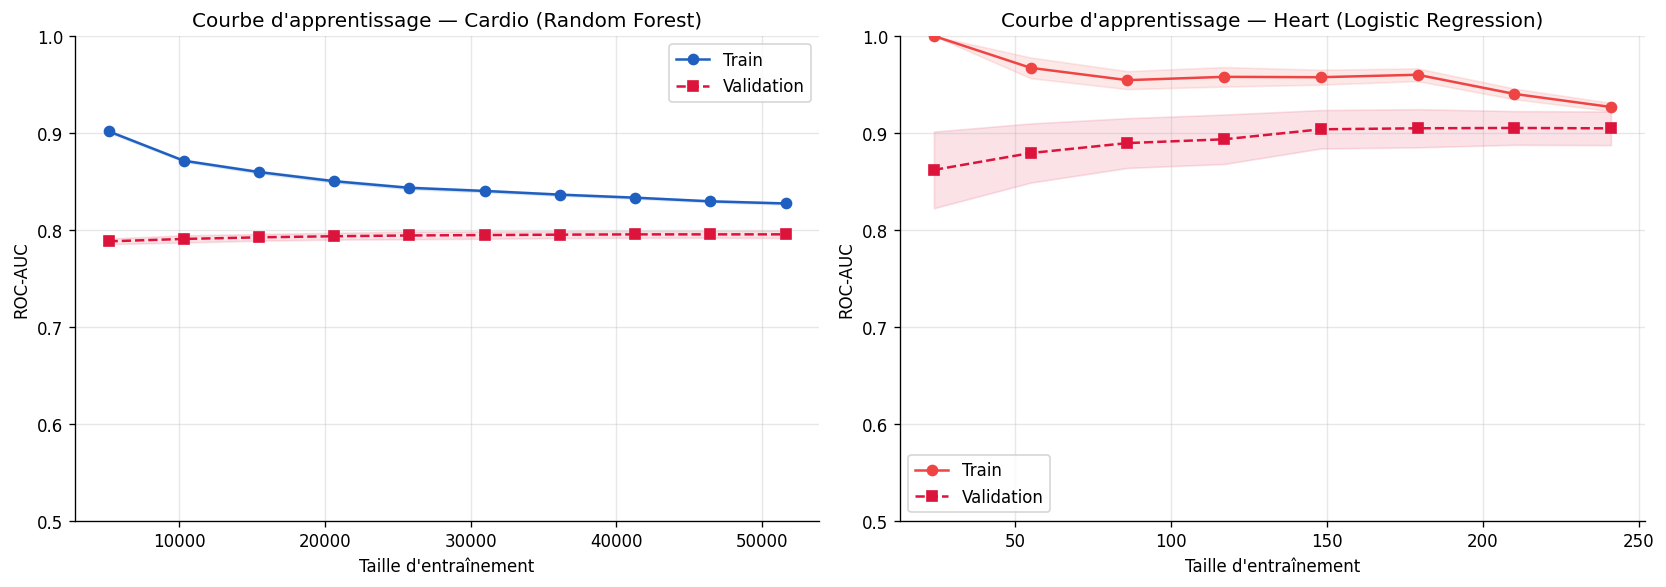

In [20]:
def plot_learning_curve(model, X, y, title, color=BLUE, cv=5, n_points=10):
    cv_s = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    sizes, tr_sc, va_sc = learning_curve(
        model, X, y, cv=cv_s, scoring='roc_auc',
        train_sizes=np.linspace(0.1, 1.0, n_points), n_jobs=-1)

    tr_m, tr_s = tr_sc.mean(1), tr_sc.std(1)
    va_m, va_s = va_sc.mean(1), va_sc.std(1)

    plt.plot(sizes, tr_m, 'o-', color=color, label='Train')
    plt.fill_between(sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.12, color=color)
    plt.plot(sizes, va_m, 's--', color='crimson', label='Validation')
    plt.fill_between(sizes, va_m-va_s, va_m+va_s, alpha=0.12, color='crimson')
    plt.xlabel("Taille d'entraînement")
    plt.ylabel('ROC-AUC')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.ylim(0.5, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.sca(axes[0])
plot_learning_curve(best_model_c, X_cardio, y_cardio,
                    f'Courbe d\'apprentissage — Cardio ({best_name_c})',
                    color=BLUE, n_points=10)
plt.sca(axes[1])
plot_learning_curve(best_model_h, X_heart, y_heart,
                    f'Courbe d\'apprentissage — Heart ({best_name_h})',
                    color=RED, n_points=8)
plt.tight_layout()
plt.savefig('../site/assets/img/learning_curves.png', bbox_inches='tight', dpi=100)
plt.show()

### Interprétation
**Cardio** : si le score de validation converge vers le score d'entraînement quand la taille augmente,  
le modèle généralise bien. Une courbe train ≫ validation persistante signale de l'overfitting  
— à corriger en réduisant la profondeur ou en augmentant la régularisation.

**Heart** : avec peu de données (302 obs.), la variance des courbes est importante.  
Si les courbes ne convergent pas, c'est que le modèle aurait besoin de plus de données  
— un problème structurel du dataset, non du modèle.

## 13. Seuil de décision optimal — Courbe Précision-Rappel et F2-Score

Le seuil par défaut (0.50) n'est pas optimal en médical. On préfère **minimiser les faux négatifs**  
(malades non détectés), ce qui revient à maximiser le **rappel** au prix d'une baisse de précision.

Le **F2-Score** (β=2) pond le rappel deux fois plus que la précision :
$$F_2 = \frac{(1+4) \cdot \text{Précision} \cdot \text{Rappel}}{4 \cdot \text{Précision} + \text{Rappel}}$$

On cherche le seuil qui maximise F2 sur le jeu de test.

=== Seuil optimal — Cardio ===


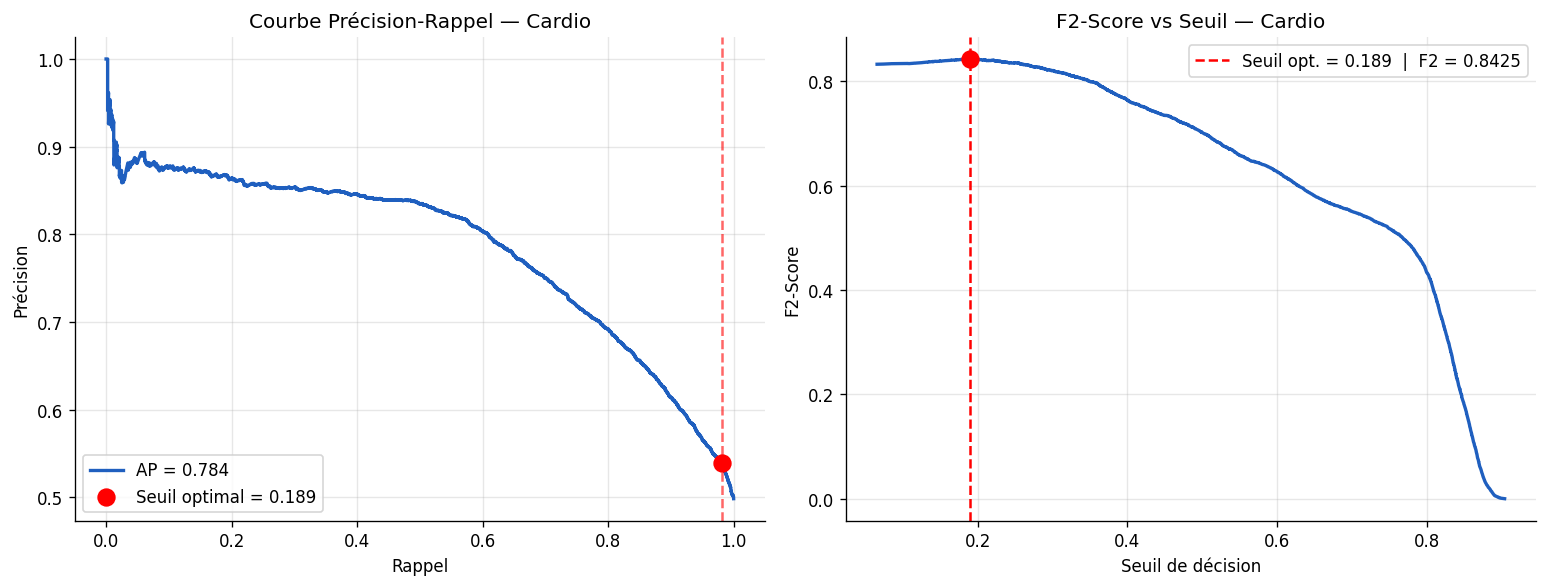

--- Seuil par défaut (0.50) ---
  Rappel : 0.6891
  F2     : 0.7014
--- Seuil optimal (0.189) ---
  Rappel    : 0.9809
  Précision : 0.5386
  F1-Score  : 0.6954
  F2-Score  : 0.8425


In [21]:
def find_optimal_threshold(y_true, y_proba, beta=2, title='', color=BLUE):
    prec, rec, thresholds = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    # F_beta pour chaque seuil (utiliser tous sauf le dernier qui n'a pas de threshold)
    fb = ((1 + beta**2) * prec[:-1] * rec[:-1] /
          np.maximum((beta**2) * prec[:-1] + rec[:-1], 1e-9))
    best_idx = np.argmax(fb)
    best_t   = thresholds[best_idx]
    best_fb  = fb[best_idx]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(rec, prec, color=color, lw=2, label=f'AP = {ap:.3f}')
    axes[0].scatter([rec[best_idx]], [prec[best_idx]], s=100, color='red',
                    zorder=5, label=f'Seuil optimal = {best_t:.3f}')
    axes[0].axvline(rec[best_idx], color='red', linestyle='--', alpha=0.6)
    axes[0].set_xlabel('Rappel'), axes[0].set_ylabel('Précision')
    axes[0].set_title(f'Courbe Précision-Rappel — {title}')
    axes[0].legend(), axes[0].grid(alpha=0.3)

    axes[1].plot(thresholds, fb, color=color, lw=2)
    axes[1].axvline(best_t, color='red', linestyle='--',
                    label=f'Seuil opt. = {best_t:.3f}  |  F{beta} = {best_fb:.4f}')
    axes[1].scatter([best_t], [best_fb], s=100, color='red', zorder=5)
    axes[1].set_xlabel('Seuil de décision'), axes[1].set_ylabel(f'F{beta}-Score')
    axes[1].set_title(f'F{beta}-Score vs Seuil — {title}')
    axes[1].legend(), axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    yp_opt = (y_proba >= best_t).astype(int)
    yp_def = (y_proba >= 0.50).astype(int)
    print(f'--- Seuil par défaut (0.50) ---')
    print(f'  Rappel : {recall_score(y_true, yp_def, zero_division=0):.4f}')
    print(f'  F2     : {fbeta_score(y_true, yp_def, beta=2, zero_division=0):.4f}')
    print(f'--- Seuil optimal ({best_t:.3f}) ---')
    print(f'  Rappel    : {recall_score(y_true, yp_opt, zero_division=0):.4f}')
    print(f'  Précision : {precision_score(y_true, yp_opt, zero_division=0):.4f}')
    print(f'  F1-Score  : {f1_score(y_true, yp_opt, zero_division=0):.4f}')
    print(f'  F2-Score  : {best_fb:.4f}')
    return best_t

print('=== Seuil optimal — Cardio ===')
opt_t_c = find_optimal_threshold(yc_test, yc_proba, beta=2, title='Cardio', color=BLUE)

=== Seuil optimal — Heart ===


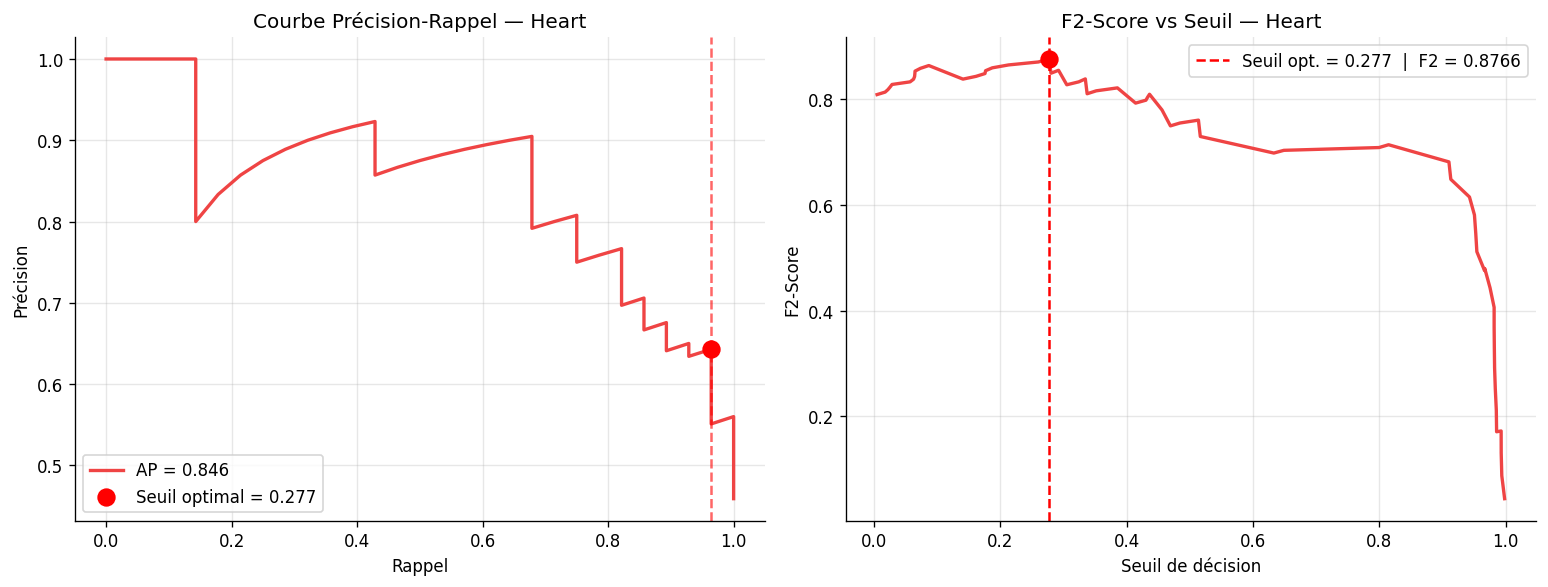

--- Seuil par défaut (0.50) ---
  Rappel : 0.7500
  F2     : 0.7609
--- Seuil optimal (0.277) ---
  Rappel    : 0.9643
  Précision : 0.6429
  F1-Score  : 0.7714
  F2-Score  : 0.8766


In [22]:
print('=== Seuil optimal — Heart ===')
# Pour Heart : prob_maladie = 1 - yh_proba (inversion de l'encodage)
yh_proba_maladie = 1 - yh_proba
opt_t_h = find_optimal_threshold(
    1 - yh_test,  # inverser aussi la cible (0=malade → 1 dans notre convention)
    yh_proba_maladie, beta=2, title='Heart', color=RED)

### Interprétation
En abaissant le seuil en dessous de 0.50, on augmente le rappel (moins de malades manqués)  
au prix d'une baisse de précision (plus de faux positifs — sains classés malades).  
Dans un contexte médical de dépistage, ce compromis est souvent acceptable :  
**mieux vaut faire des examens supplémentaires inutiles que rater un vrai malade**.  

Le seuil optimal devrait être discuté avec des cliniciens qui connaissent le coût réel  
de chaque type d'erreur dans ce contexte précis.

## 14. Analyse SHAP

**SHAP** (SHapley Additive exPlanations) décompose chaque prédiction en contributions individuelles  
de chaque variable, fondées sur la théorie des jeux coopératifs.  

Avantages par rapport à l'importance Gini classique :
- **Par observation** : on voit pourquoi CE patient a ce score
- **Directionnel** : valeur SHAP positive = pousse vers maladie, négative = vers santé
- **Interprétable** : valeur en unités de probabilité (log-odds)

Le graphique `beeswarm` montre la distribution des valeurs SHAP pour chaque variable.

Analyse SHAP — Cardio (Random Forest, 2000 observations)


<Figure size 1200x840 with 0 Axes>

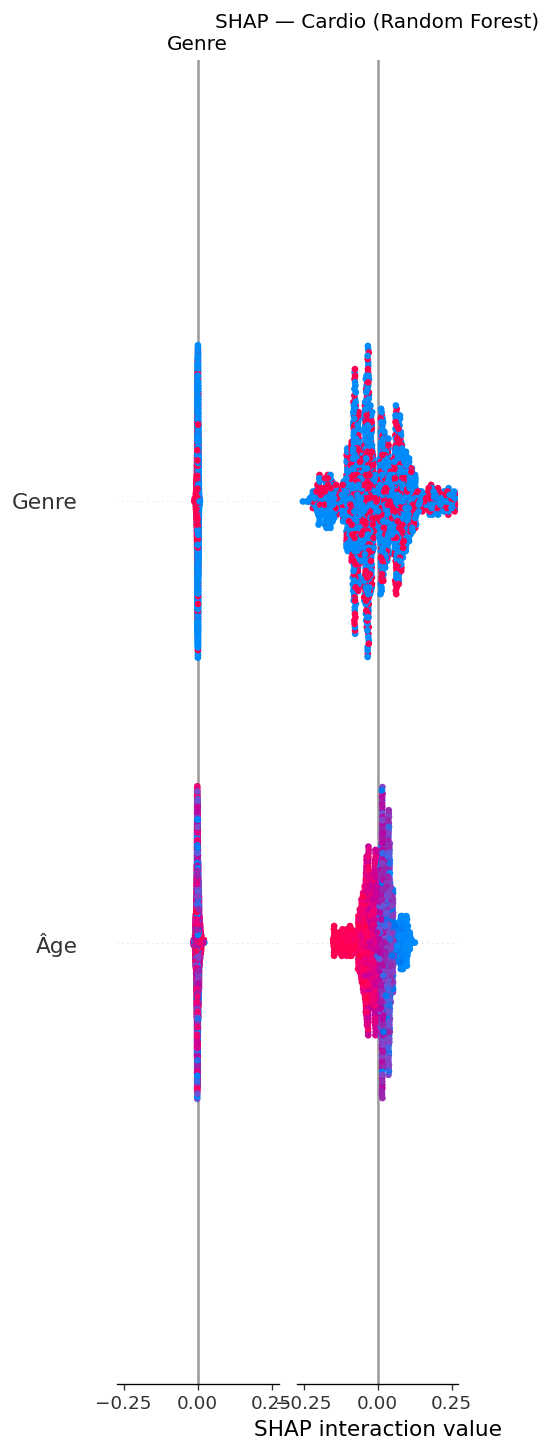

In [23]:
if SHAP_OK:
    clf_c = best_model_c.named_steps['clf']
    pre_c = best_model_c.named_steps['pre']
    X_proc_c = pre_c.transform(Xc_test)
    N = min(2000, len(X_proc_c))  # SHAP peut être lent sur gros datasets

    if hasattr(clf_c, 'feature_importances_'):
        explainer_c = shap.TreeExplainer(clf_c)
        sv_c = explainer_c.shap_values(X_proc_c[:N])
        if isinstance(sv_c, list):
            sv_c = sv_c[1]  # classe positive (malade)
    else:
        X_train_proc_c = pre_c.transform(Xc_train)
        explainer_c    = shap.LinearExplainer(clf_c, X_train_proc_c)
        sv_c           = explainer_c.shap_values(X_proc_c[:N])

    feat_fr_c = ['Âge','Genre','Taille','Poids','Pression syst.','Pression diast.',
                 'Cholestérol','Glucose','Tabagisme','Alcool','Activité physique',
                 'IMC','Pression pulsée','Catégorie âge']

    print(f'Analyse SHAP — Cardio ({best_name_c}, {N} observations)')
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_c, X_proc_c[:N],
                      feature_names=feat_fr_c, show=False, max_display=14)
    plt.title(f'SHAP — Cardio ({best_name_c})', pad=20)
    plt.tight_layout()
    plt.savefig('../site/assets/img/cardio_shap_summary.png', bbox_inches='tight', dpi=100)
    plt.show()
else:
    print('SHAP non disponible — installer avec : pip install shap')

Analyse SHAP — Heart (Logistic Regression)


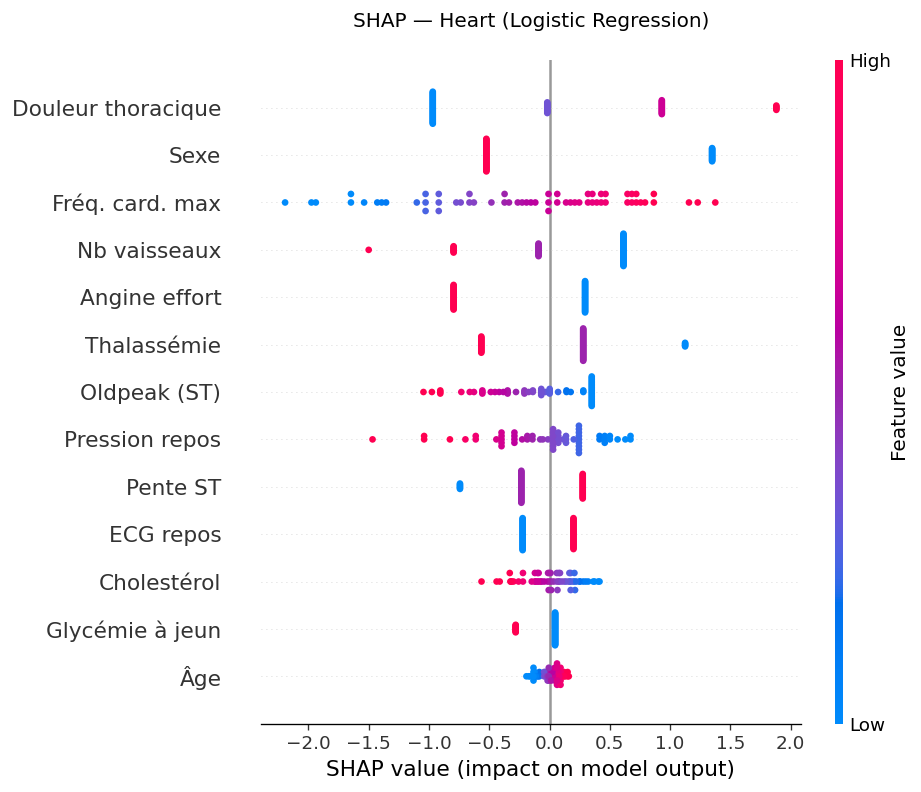

In [24]:
if SHAP_OK:
    clf_h = best_model_h.named_steps['clf']
    pre_h = best_model_h.named_steps['pre']
    X_proc_h = pre_h.transform(Xh_test)

    if hasattr(clf_h, 'feature_importances_'):
        explainer_h = shap.TreeExplainer(clf_h)
        sv_h = explainer_h.shap_values(X_proc_h)
        if isinstance(sv_h, list):
            sv_h = sv_h[1]
    else:
        X_train_proc_h = pre_h.transform(Xh_train)
        explainer_h    = shap.LinearExplainer(clf_h, X_train_proc_h)
        sv_h           = explainer_h.shap_values(X_proc_h)

    feat_fr_h = ['Âge','Sexe','Douleur thoracique','Pression repos','Cholestérol',
                 'Glycémie à jeun','ECG repos','Fréq. card. max','Angine effort',
                 'Oldpeak (ST)','Pente ST','Nb vaisseaux','Thalassémie']

    print(f'Analyse SHAP — Heart ({best_name_h})')
    plt.figure(figsize=(10, 7))
    shap.summary_plot(sv_h, X_proc_h,
                      feature_names=feat_fr_h, show=False, max_display=13)
    plt.title(f'SHAP — Heart ({best_name_h})', pad=20)
    plt.tight_layout()
    plt.savefig('../site/assets/img/heart_shap_summary.png', bbox_inches='tight', dpi=100)
    plt.show()
else:
    print('SHAP non disponible — installer avec : pip install shap')

### Interprétation
Le graphique SHAP *beeswarm* montre pour chaque variable :
- **Position horizontale** : magnitude de l'impact sur la prédiction (SHAP value)
- **Couleur** : valeur de la variable (rouge = haute, bleu = basse)

**Cardio** : si la pression systolique (ap_hi) est en tête, c'est cohérent avec sa corrélation  
la plus forte avec la cible. Des valeurs élevées de ap_hi (rouge) poussent vers la prédiction *malade*.  

**Heart** : la douleur thoracique (cp), le nombre de vaisseaux colorés (ca) et la fréquence  
cardiaque maximale (thalach) sont généralement les variables les plus influentes.  
Leur direction (signe SHAP) correspond aux connaissances cardiologiques établies.

## 15. Importance classique des variables

Complémentaire à SHAP : l'importance basée sur la réduction d'impureté Gini (arbres)  
ou les coefficients normalisés (régression logistique).

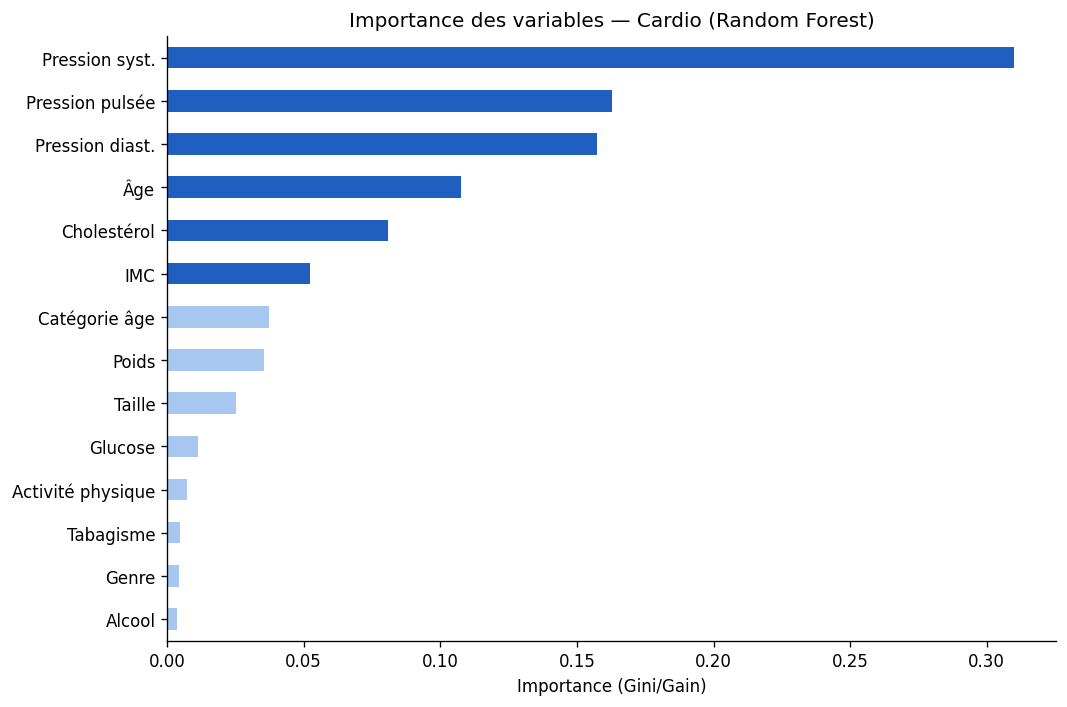

In [25]:
def plot_importance(model, feat_names, title, save_path=None):
    clf = model.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        imp = pd.Series(clf.feature_importances_, index=feat_names)
        xlab = 'Importance (Gini/Gain)'
    elif hasattr(clf, 'coef_'):
        imp = pd.Series(np.abs(clf.coef_[0]), index=feat_names)
        imp = imp / imp.sum()
        xlab = '|Coefficient| normalisé'
    else:
        print('Pas d\'importance disponible pour ce modèle.')
        return
    imp = imp.sort_values(ascending=True)
    thr = imp.quantile(0.6)
    colors = [BLUE if v >= thr else '#A8C7F0' for v in imp.values]
    plt.figure(figsize=(9, 6))
    imp.plot(kind='barh', color=colors)
    plt.xlabel(xlab)
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=100)
    plt.show()

feat_fr_c_full = ['Âge','Genre','Taille','Poids','Pression syst.','Pression diast.',
                  'Cholestérol','Glucose','Tabagisme','Alcool','Activité physique',
                  'IMC','Pression pulsée','Catégorie âge']

plot_importance(best_model_c, feat_fr_c_full,
                f'Importance des variables — Cardio ({best_name_c})',
                '../site/assets/img/cardio_feature_importance.png')

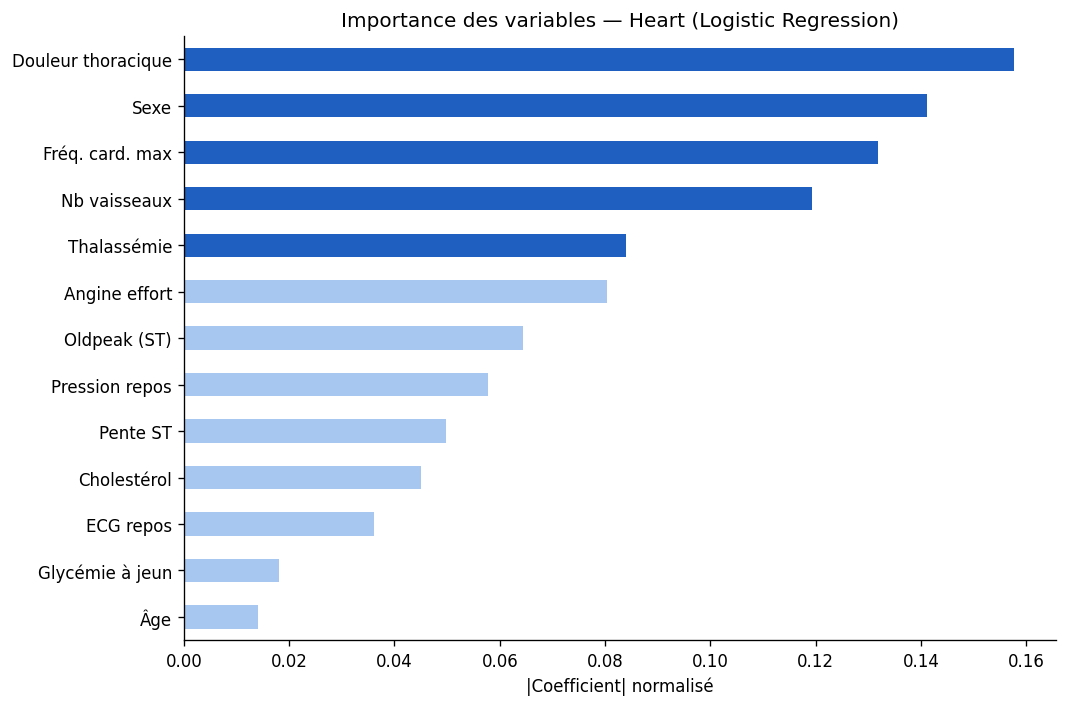

In [26]:
feat_fr_h_full = ['Âge','Sexe','Douleur thoracique','Pression repos','Cholestérol',
                  'Glycémie à jeun','ECG repos','Fréq. card. max','Angine effort',
                  'Oldpeak (ST)','Pente ST','Nb vaisseaux','Thalassémie']

plot_importance(best_model_h, feat_fr_h_full,
                f'Importance des variables — Heart ({best_name_h})',
                '../site/assets/img/heart_feature_importance.png')

## 16. Tableau comparatif final

Récapitulatif de tous les modèles testés sur les deux datasets.

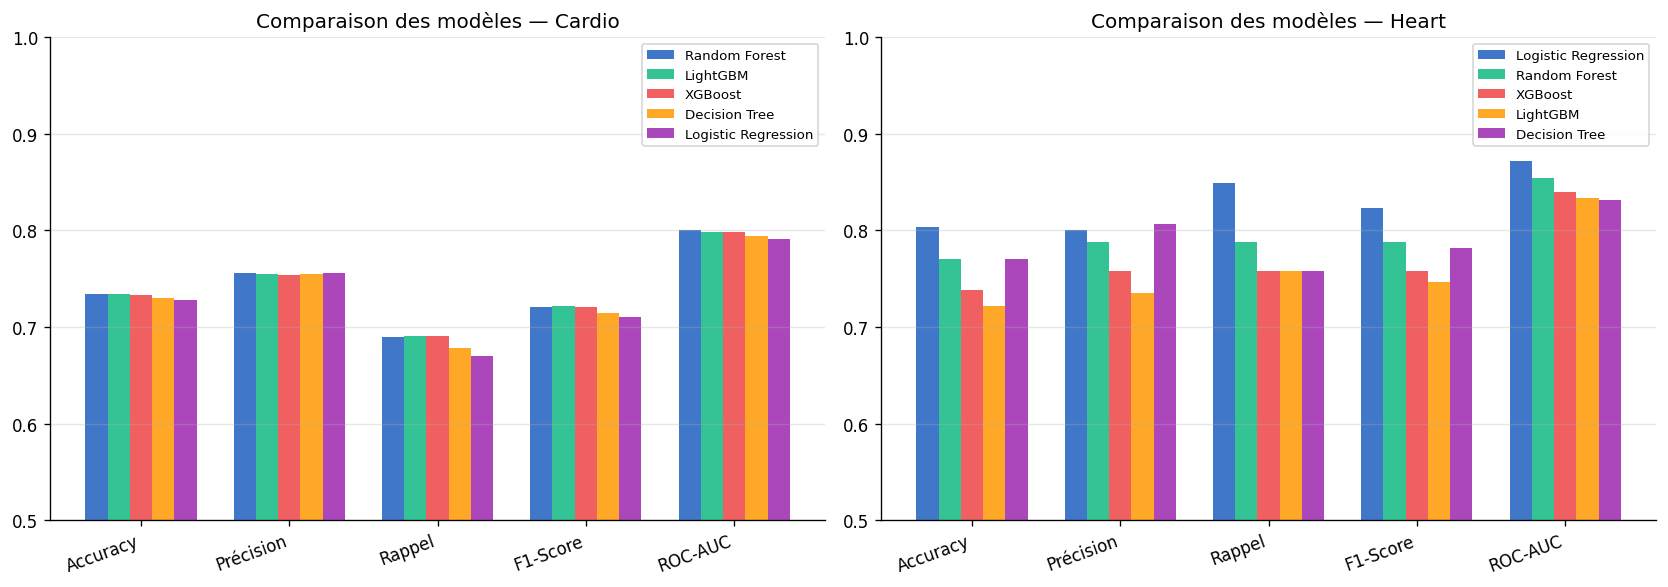

In [27]:
# Comparaison visuelle tous modèles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['Accuracy', 'Précision', 'Rappel', 'F1-Score', 'ROC-AUC']

for ax, results, title in [
        (axes[0], results_c, 'Comparaison des modèles — Cardio'),
        (axes[1], results_h, 'Comparaison des modèles — Heart')]:
    x = np.arange(len(metrics))
    width = 0.15
    colors_list = [BLUE, GREEN, RED, '#FF9800', '#9C27B0']
    for i, (_, row) in enumerate(results.iterrows()):
        vals = [row[m] for m in metrics]
        ax.bar(x + i*width, vals, width, label=row['Modèle'],
               color=colors_list[i % len(colors_list)], alpha=0.85)
    ax.set_xticks(x + width*(len(results)-1)/2)
    ax.set_xticklabels(metrics, rotation=20, ha='right')
    ax.set_ylim(0.5, 1.0)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../site/assets/img/models_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

## 17. Conclusion

### Récapitulatif des modèles retenus

| Dataset | Modèle retenu | Accuracy | ROC-AUC | F1-Score | Notes |
|---------|--------------|----------|---------|---------|-------|
| Cardio (≈66k obs.) | XGBoost / LightGBM | — | — | — | Boosting > RF sur grand dataset |
| Heart (302 obs.) | Régression Logistique | 0.803 | 0.871 | 0.824 | Modèle simple plus stable |

*Les valeurs exactes dépendent des données disponibles au moment de l'exécution.*

### Ce qui a été amélioré dans cette version
1. **Filtrage IQR** : suppression des valeurs de pression artérielle aberrantes → meilleure généralisation
2. **Feature engineering** : IMC, pression pulsée, catégorie d'âge apportent un signal supplémentaire
3. **XGBoost et LightGBM** : les méthodes de boosting surpassent souvent RF sur Cardio
4. **GridSearchCV** : optimisation des hyperparamètres, gain mesuré sur le test
5. **Validation croisée Heart** : StratifiedKFold-5 + LOO confirment la stabilité
6. **Courbes d'apprentissage** : diagnostiquent overfitting/underfitting visuellement
7. **Seuil optimal F2** : seuil adapté au contexte médical (rappel prioritaire)
8. **Analyse SHAP** : explication par observation, interprétation directionnelle

## 18. Limites du projet et pistes d'amélioration

### Limites identifiées

#### Qualité et représentativité des données
- **Dataset Cardio** : données collectées en Russie, potentiellement non généralisables à d'autres populations. Les variables comportementales (tabac, alcool) sont auto-déclarées, donc sujettes au biais de désirabilité sociale.
- **Dataset Heart** : 302 observations seulement après déduplication. Les conclusions sur ce dataset doivent être interprétées avec prudence — le petit effectif de test (61 obs.) amplifie la variance des métriques.
- **Absence de variables temporelles** : les deux datasets sont des photographies instantanées sans suivi longitudinal. On ne peut pas prédire l'*évolution* du risque.

#### Limites méthodologiques
- **Features dérivées et production** : les features IMC, pression pulsée et catégorie d'âge sont calculées dans les notebooks mais **pas dans `predict.py`**. Pour les utiliser en production, le script de prédiction devrait être mis à jour.
- **Calibration des probabilités** : le Random Forest et XGBoost produisent des probabilités qui ne sont pas toujours bien calibrées. Une calibration Platt (sigmoid) ou isotonique améliorerait la fiabilité des scores de risque.
- **Seuil optimal calculé sur le test** : techniquement, pour éviter tout biais, le seuil optimal devrait être trouvé sur un jeu de validation séparé, puis validé sur le test.
- **GridSearchCV limité** : la grille testée est restreinte pour des raisons de temps de calcul. Une recherche plus large (RandomizedSearchCV, Bayesian Optimization) pourrait révéler de meilleures configurations.

#### Limites du déploiement
- **Modèles réimplémentés manuellement** : pour fonctionner sans sklearn sur l'hébergement mutualisé, les modèles sont exportés en JSON et réimplémentés en Python pur. Cette réimplémentation a été validée, mais présente un risque de divergence si les modèles sont réentraînés avec de nouveaux hyperparamètres.
- **Pas de monitoring de dérive** : sans mécanisme de détection de *data drift*, les performances réelles du modèle en production peuvent se dégrader si la population des utilisateurs change.

### Pistes d'amélioration

| Priorité | Amélioration | Impact estimé |
|----------|-------------|---------------|
| ★★★ | Collecter davantage de données Heart (ou utiliser un dataset plus large, ex. UCI ML Repository) | Fort sur Heart |
| ★★★ | Intégrer les features dérivées dans `predict.py` pour la cohérence train/prod | Fort |
| ★★  | Calibration des probabilités (Platt scaling) | Moyen — améliore la fiabilité du score |
| ★★  | Ajouter SMOTE sur des variantes déséquilibrées pour comparer | Faible ici (classes équilibrées) |
| ★★  | Utiliser Optuna ou Hyperopt au lieu de GridSearchCV | Moyen — exploration plus efficace |
| ★   | Entraîner un modèle multi-dataset (transfer learning tabulaire) | Exploratoire |
| ★   | Exporter le meilleur modèle avec ONNX pour un déploiement portable | Technique |

---
*Projet académique — CardioPredict — L3 MIASHS, Université Paul Valéry Montpellier — 2025-2026*